In [1]:
import warnings
warnings.filterwarnings("ignore")

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

import scvi
import torch
import matplotlib.pyplot as plt
import anndata as ad
import scipy.sparse as sp
import spVIPESmulti

import seaborn as sns
from pathlib import Path

np.random.seed(0)
torch.manual_seed(0)
sc.settings.set_figure_params(dpi=80, frameon=False)

print(f"spVIPESmulti  : {spVIPESmulti.__version__}")
print(f"scvi-tools: {scvi.__version__}")
print(f"scanpy   : {sc.__version__}")
print(f"torch    : {torch.__version__} (CUDA available: {torch.cuda.is_available()})")
print(f"anndata  : {ad.__version__}")

spVIPESmulti  : 1.0.0
scvi-tools: 1.4.2
scanpy   : 1.12.1
torch    : 2.11.0+cu128 (CUDA available: True)
anndata  : 0.12.11


In [2]:
root = Path("/exports/para-lipg-hpc/mdmanurung/spVIPESmulti/docs/notebooks/")
path_obs = root/"data/bcells_obs.csv"
path_rna = root/"data/bcells_rna.csv"

In [3]:
adata = ad.read_csv(path_rna, first_column_names=True)
obs = pd.read_csv(path_obs, index_col=0)
adata.obs = obs
adata.layers["counts"] = adata.X.copy()

In [4]:
adata.obs["antigen_class"] = (
    adata.obs["antigen_specific"]
    .astype(str)
    .str.strip()
    .apply(lambda x: "Negative" if x.lower() == "negative" else "Positive")
)
adata.obs["antigen_class"].value_counts()
adata = adata[adata.obs["antigen_class"] == "Positive"]
adata

View of AnnData object with n_obs × n_vars = 9978 × 38605
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'nCount_HTO', 'nFeature_HTO', 'batch', 'cellhashr_id', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_hemo', 'scdblfinder_score', 'scdblfinder_class', 'scran_size_factors', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'clonalProportion', 'clonalFrequency', 'cloneSize', 'barcode', 'IGH', 'cdr3_aa1', 'cdr3_nt1', 'IGLC', 'cdr3_nt2', 'has_bcr', 'NANP', 'NJunction', 'qc_keep', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'seurat_clusters', 'MG_nn_res.0.1', 'MG_res.0.1', 'MG_nn_res.0.2', 'MG_res.0.2', 'MG_nn_res.0.3', 'MG_res.0.3', 'MG_nn_res.0.4', 'MG_res.0.4', 'MG_nn_res.0.5', 'MG_res.0.5', 'MG_nn_res.0.6', 'MG_res.0.6', 'MG_nn_res.0.7', 'MG_res.0.7', 'MG_nn_res.0.8', 'MG_res.0.8', 'MG_nn_res.0.9', 'MG_res.0.9', 'MG_nn_res.1', 'MG_res.1', 'MG_nn_res.1.1', 'MG_res.1.1', 'MG_nn_res.1.2', 'MG_res.1.2', 'MG_nn_res.1.3', 'MG_res

In [5]:
adata.obs["volunteer"].value_counts()

volunteer
817     2887
1160    2421
746     1760
825     1220
1333     852
888      838
Name: count, dtype: int64

In [6]:
adata.obs["batch"].value_counts()

batch
batch3    5140
batch2    3200
batch1    1638
Name: count, dtype: int64

In [7]:
adata.obs["time"].value_counts()

time
I2+14    2088
I3-1     1728
ZC-1     1667
I3+14    1377
I2-1     1348
I1+14    1266
I1-1      504
Name: count, dtype: int64

In [8]:
adata.obs["cluster_label"].value_counts()

cluster_label
Atypical           3155
Activated          2284
Classical          1653
Activated MZ        772
Naïve               687
Pre-Plasmablast     637
Transitional        434
Plasmablast         356
Name: count, dtype: int64

In [9]:
adata.obs["antigen_specific"].value_counts()

antigen_specific
CRXV     6898
NANP     2207
Njunc     873
Name: count, dtype: int64

In [10]:
adata.obs["batch_group"] = adata.obs["antigen_specific"] + "_" + adata.obs["batch"]

In [11]:
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor="seurat_v3", batch_key="antigen_specific")
adata = adata[:, adata.var["highly_variable"]].copy()

In [12]:
# Split into per-time-point AnnData objects
antigen_specific = sorted(adata.obs["antigen_specific"].unique())
adatas_dict = {}
for ac in antigen_specific:
    sub = adata[adata.obs["antigen_specific"] == ac].copy()
    # Clean up — prepare_adatas doesn't need extra obsm/uns
    sub.uns = {}
    sub.obsm = {}
    sub.layers = {}
    adatas_dict[ac] = sub
    print(f"  {ac}: {sub.shape}")

# Concatenate with spVIPESmulti
adata_spv = spVIPESmulti.data.prepare_adatas(adatas_dict)

print(f"\nConcatenated AnnData: {adata_spv.shape}")
print(f"Groups             : {list(adata_spv.uns['groups_mapping'].values())}")
print(f"Group sizes        : {[len(g) for g in adata_spv.uns['groups_obs_indices']]}")

  CRXV: (6898, 3000)
  NANP: (2207, 3000)
  Njunc: (873, 3000)

Concatenated AnnData: (9978, 9000)
Groups             : ['CRXV', 'NANP', 'Njunc']
Group sizes        : [6898, 2207, 873]


In [13]:
spVIPESmulti.model.spVIPESmulti.setup_anndata(
    adata_spv,
    groups_key="antigen_specific",
    label_key="cluster_label",
    batch_key="batch"
)

INFO     spVIPESmulti: === spVIPESmulti AnnData Setup ===                                                          
INFO     spVIPESmulti: Setting up with groups_key: 'antigen_specific'                                              
INFO     spVIPESmulti: Labels: Using 'cluster_label' from adata.obs                                                
INFO     spVIPESmulti: --- Product of Experts (PoE) Configuration ---                                              
INFO     spVIPESmulti: Will use: Label-based PoE                                                                   


In [14]:
# Model hyperparameters
N_SHARED   = 20
N_PRIVATE  = 10
N_HIDDEN   = 128
DROPOUT    = 0.1
MAX_EPOCHS = 300
BATCH_SIZE = 512
KL_WARMUP  = 75


model_spv = spVIPESmulti.model.spVIPESmulti(
    adata_spv,
    n_hidden=N_HIDDEN,
    n_dimensions_shared=N_SHARED,
    n_dimensions_private=N_PRIVATE,
    dropout_rate=DROPOUT,
    disentangle_preset="no_contrastive",
    disentangle_warmup=False,
    # use_nf_prior=True,
    # nf_type="NSF",               # "NSF" or "MAF"
    # nf_transforms=3,
    # nf_target="both",          # "shared", "private", or "both"
)

INFO     spVIPESmulti: The model has been initialized                                                              


In [15]:
# Get group indices from uns (canonical approach matching prepare_adatas output)
group_indices_list = [list(map(int, g)) for g in adata_spv.uns["groups_obs_indices"]]
print("Group sizes:", [len(g) for g in group_indices_list])

# Train
model_spv.train(
    group_indices_list,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    train_size=0.9,
    early_stopping=True,
    early_stopping_patience=20,
    n_epochs_kl_warmup=KL_WARMUP,
    check_val_every_n_epoch=10,
    early_stopping_monitor="elbo_validation",
    plan_kwargs={
        "lr": 1e-3,
        "lr_scheduler_metric": "elbo_train"},
)


Group sizes: [6898, 2207, 873]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/300 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.


In [16]:
model_spv.save("results/spvipes_bcells_nowarmup")

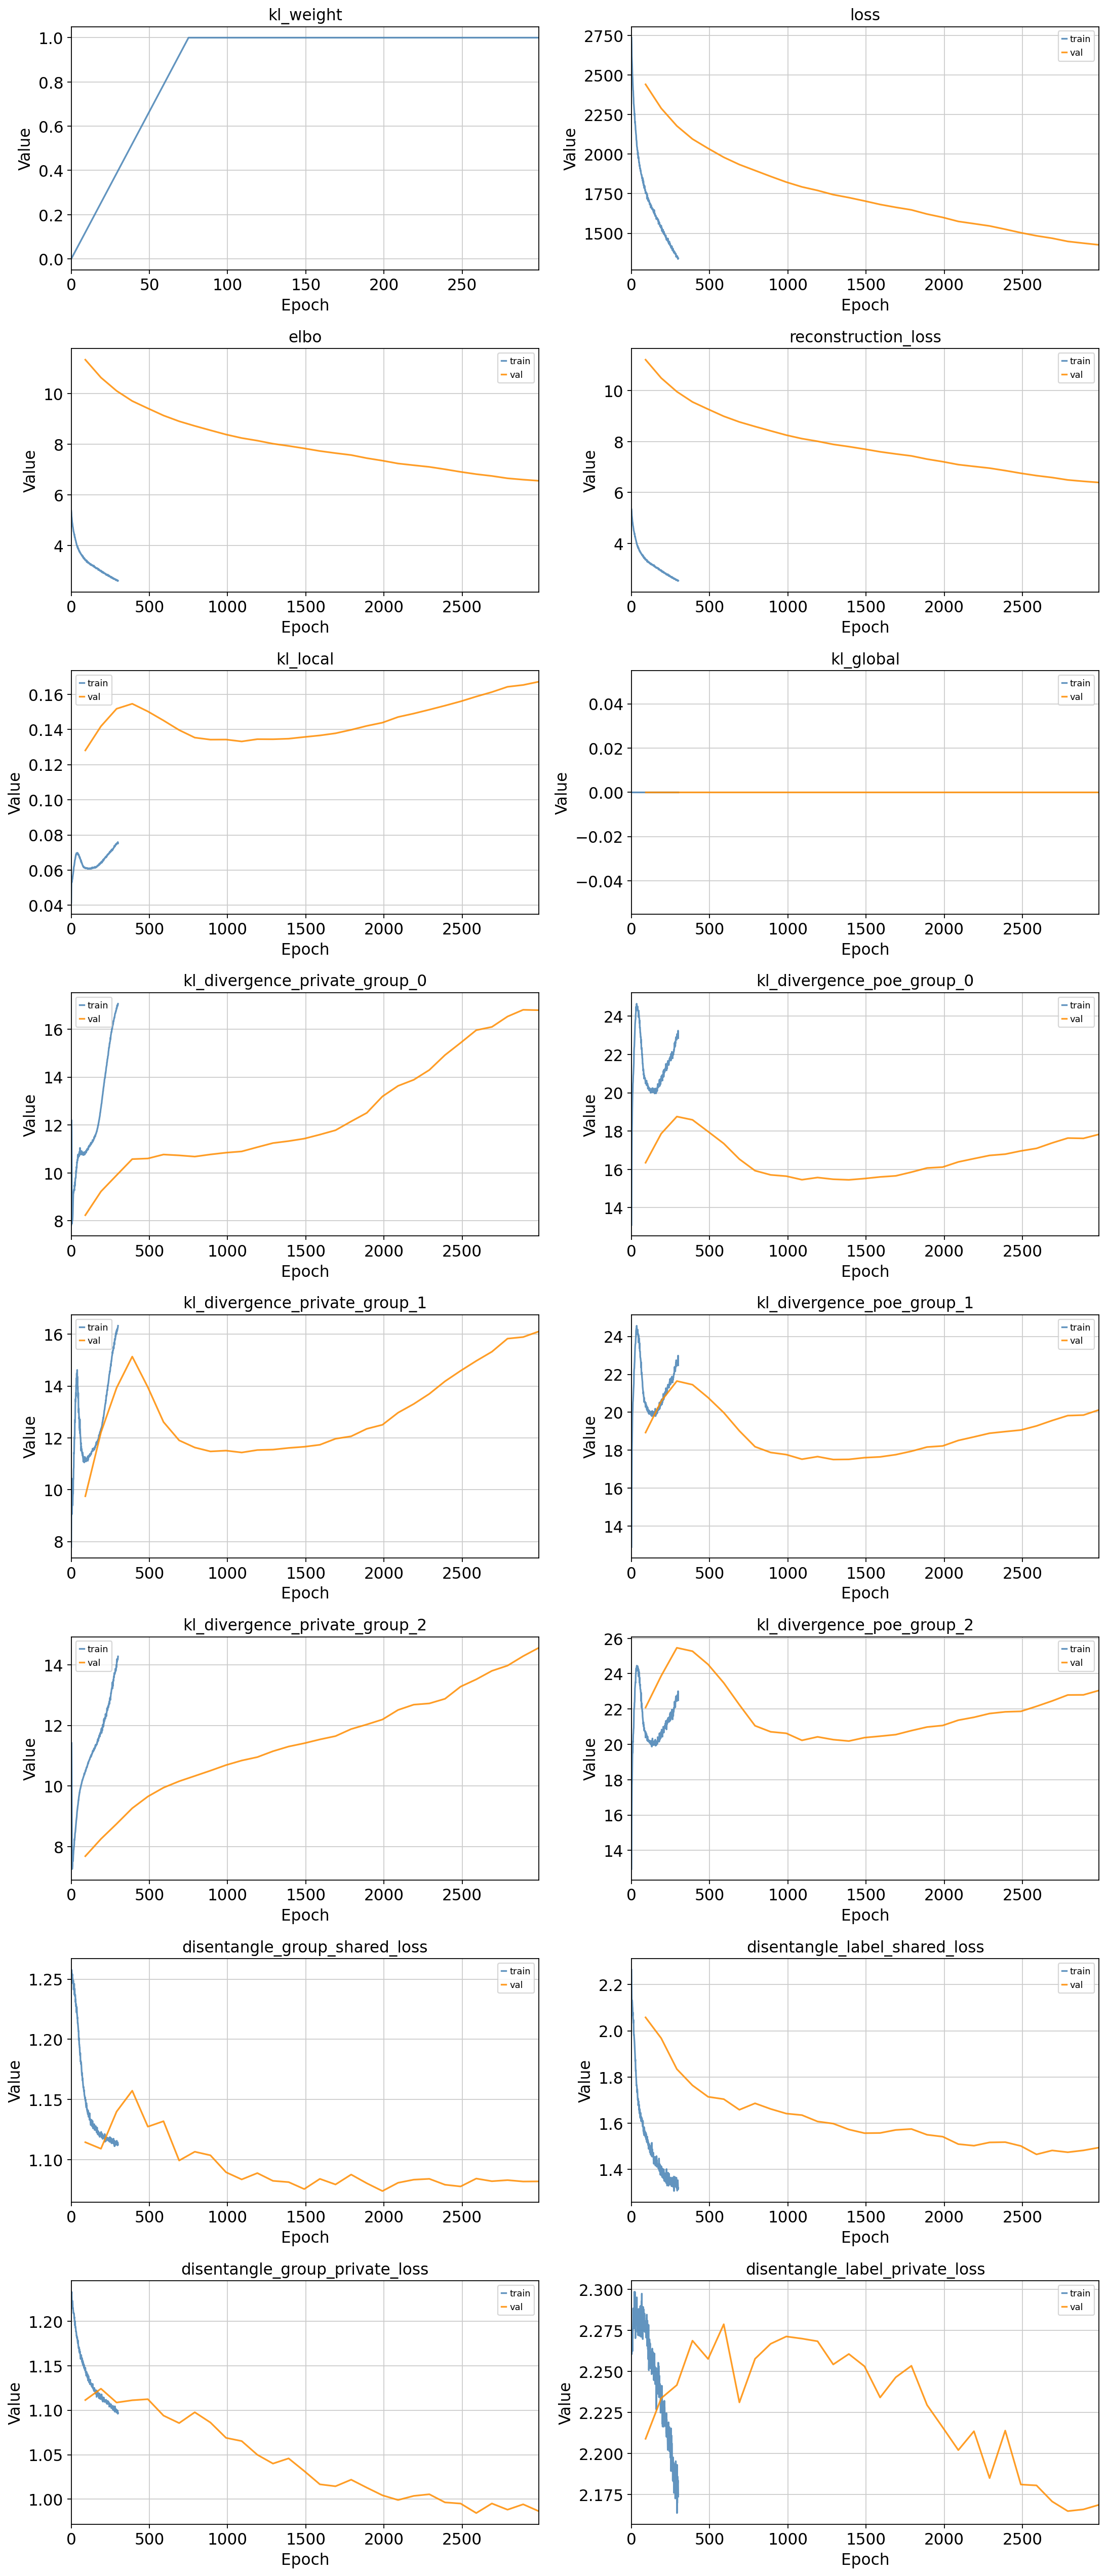

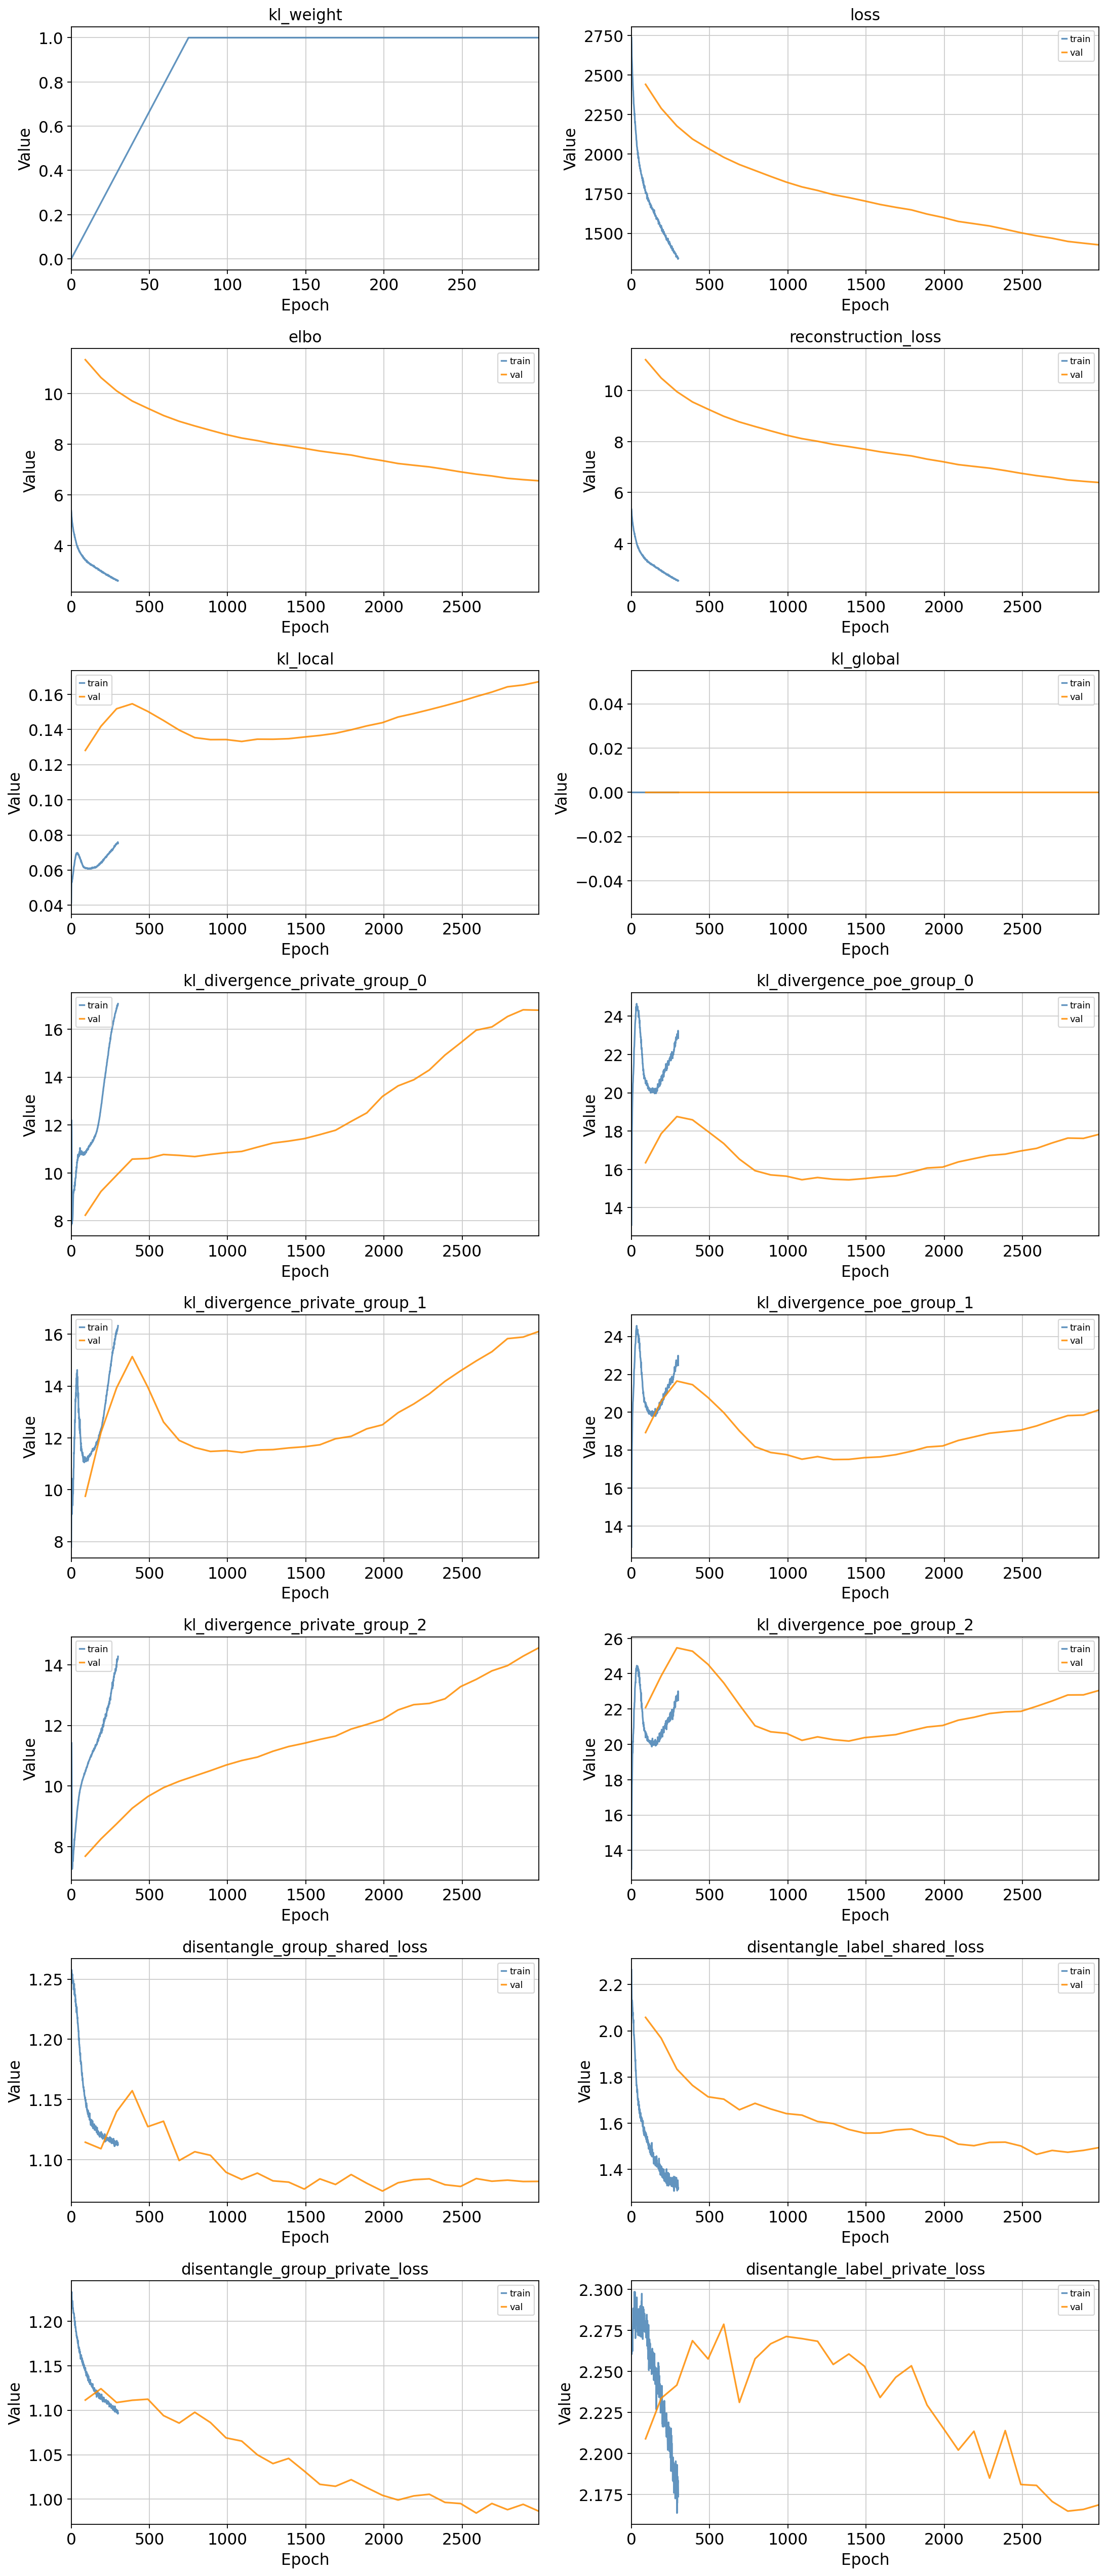

In [17]:
spVIPESmulti.pl.training_curves(model_spv)

In [18]:
payload = model_spv.embed(batch_size=1024)
# payload["keys"]["shared"] == "X_spvm_shared"

In [19]:
group_indices_list = [list(map(int, g)) for g in adata_spv.uns["groups_obs_indices"]]
latents = model_spv.get_latent_representation(group_indices_list, batch_size=1024)
spVIPESmulti.utils.store_latents(adata_spv, latents, group_indices_list)

AnnData object with n_obs × n_vars = 9978 × 9000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'nCount_HTO', 'nFeature_HTO', 'batch', 'cellhashr_id', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_hemo', 'scdblfinder_score', 'scdblfinder_class', 'scran_size_factors', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'clonalProportion', 'clonalFrequency', 'cloneSize', 'barcode', 'IGH', 'cdr3_aa1', 'cdr3_nt1', 'IGLC', 'cdr3_nt2', 'has_bcr', 'NANP', 'NJunction', 'qc_keep', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'seurat_clusters', 'MG_nn_res.0.1', 'MG_res.0.1', 'MG_nn_res.0.2', 'MG_res.0.2', 'MG_nn_res.0.3', 'MG_res.0.3', 'MG_nn_res.0.4', 'MG_res.0.4', 'MG_nn_res.0.5', 'MG_res.0.5', 'MG_nn_res.0.6', 'MG_res.0.6', 'MG_nn_res.0.7', 'MG_res.0.7', 'MG_nn_res.0.8', 'MG_res.0.8', 'MG_nn_res.0.9', 'MG_res.0.9', 'MG_nn_res.1', 'MG_res.1', 'MG_nn_res.1.1', 'MG_res.1.1', 'MG_nn_res.1.2', 'MG_res.1.2', 'MG_nn_res.1.3', 'MG_res.1.3', 'M

In [20]:
# Shared latent UMAP (all groups integrated):
spVIPESmulti.utils.compute_shared_umap(adata_spv)

AnnData object with n_obs × n_vars = 9978 × 9000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'nCount_HTO', 'nFeature_HTO', 'batch', 'cellhashr_id', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_hemo', 'scdblfinder_score', 'scdblfinder_class', 'scran_size_factors', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'clonalProportion', 'clonalFrequency', 'cloneSize', 'barcode', 'IGH', 'cdr3_aa1', 'cdr3_nt1', 'IGLC', 'cdr3_nt2', 'has_bcr', 'NANP', 'NJunction', 'qc_keep', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'seurat_clusters', 'MG_nn_res.0.1', 'MG_res.0.1', 'MG_nn_res.0.2', 'MG_res.0.2', 'MG_nn_res.0.3', 'MG_res.0.3', 'MG_nn_res.0.4', 'MG_res.0.4', 'MG_nn_res.0.5', 'MG_res.0.5', 'MG_nn_res.0.6', 'MG_res.0.6', 'MG_nn_res.0.7', 'MG_res.0.7', 'MG_nn_res.0.8', 'MG_res.0.8', 'MG_nn_res.0.9', 'MG_res.0.9', 'MG_nn_res.1', 'MG_res.1', 'MG_nn_res.1.1', 'MG_res.1.1', 'MG_nn_res.1.2', 'MG_res.1.2', 'MG_nn_res.1.3', 'MG_res.1.3', 'M

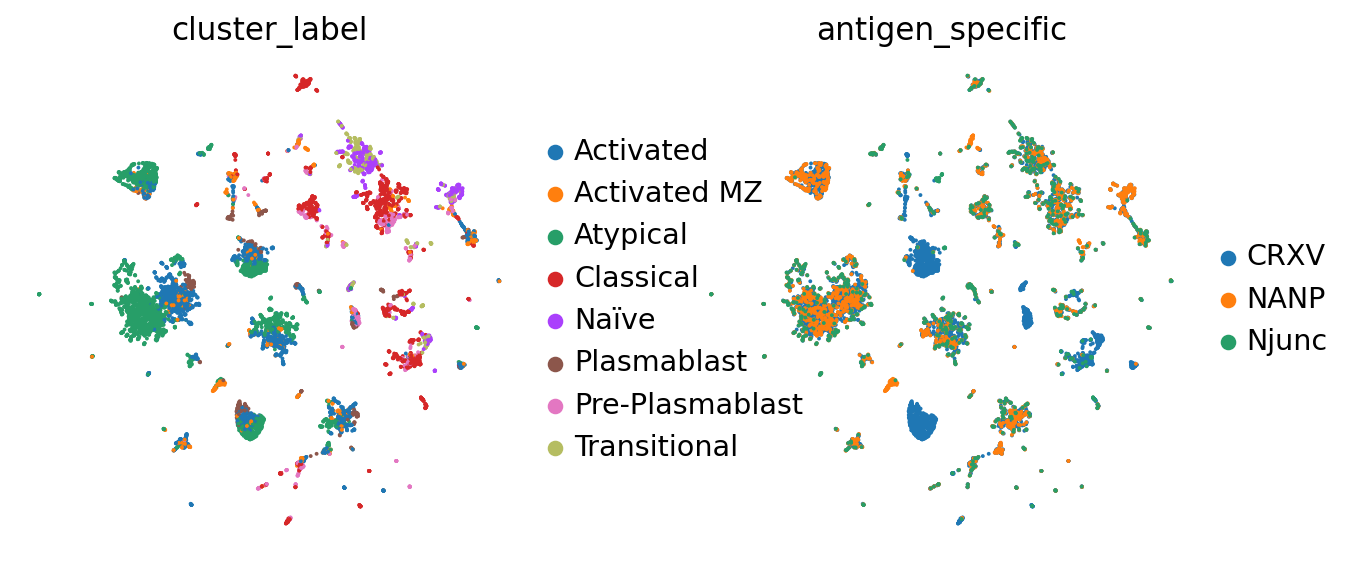

In [21]:
spVIPESmulti.pl.umap_shared(adata_spv, color=["cluster_label", "antigen_specific"])